# Viral Treatment Outcome Classification
## Support Vector Machine Classification

This project applies Support Vector Machine classification to predict virus presence in mice based on dosage levels of two experimental treatments. The dataset provides a clean two-dimensional feature space that makes it ideal for exploring how kernel choice and hyperparameter tuning affect the SVM decision boundary.

### Dataset

The mouse viral study dataset records two treatment dosage levels (Med_1_mL and Med_2_mL) and a binary outcome indicating whether the virus was detected post-treatment. The goal is to identify the dosage combinations that predict treatment success.

### Workflow

1. **EDA:** visualize the two-dimensional dosage feature space by viral outcome
2. **SVM with Linear Kernel:** establish a separating hyperplane baseline
3. **Hyperparameter Exploration:** compare C values, kernels (linear, RBF, sigmoid, poly), and gamma
4. **GridSearchCV:** identify the optimal C and kernel combination via cross-validation

### Key Concepts Demonstrated

- Effect of regularization parameter C on margin width and boundary smoothness
- Kernel trick: mapping features to higher-dimensional space for non-linear separation
- Gamma: how tightly the RBF kernel follows individual training points

### Stack

Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn

---
## Part 1: Setup & Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

%matplotlib inline
sns.set_style('darkgrid')

# plot_svm_boundary is a helper function that visualizes the SVM decision boundary.
# Source: https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html
# Make sure the supplemental .py file is in the same directory before running.
from svm_boundary_plotter import plot_svm_boundary

In [ ]:
df = pd.read_csv("../DATA/mouse_viral_study.csv")

In [ ]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [ ]:
df.columns

Index(['Med_1_mL', 'Med_2_mL', 'Virus Present'], dtype='object')

### Dosage Feature Space by Viral Outcome

Plotting both treatment dosage levels against each other, colored by viral presence, shows whether the classes are linearly separable — a key factor in choosing an SVM kernel.

<AxesSubplot:xlabel='Med_1_mL', ylabel='Med_2_mL'>

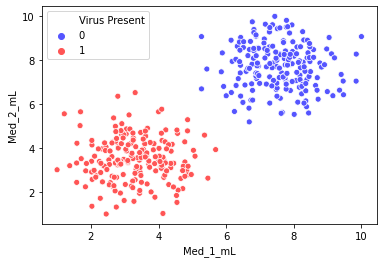

In [ ]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',
                data=df,palette='seismic')

---
## Part 2: SVM with Linear Kernel

The goal of SVM is to find the hyperplane that maximizes the margin between classes. With a high C value, the model prioritizes correct classification of all training points, resulting in a tight margin.

In [ ]:
y = df['Virus Present']
X = df.drop('Virus Present', axis=1)

In [ ]:
model = SVC(kernel='linear', C=1000)
model.fit(X, y)
plot_svm_boundary(model, X, y)

SVC(C=1000, kernel='linear')

---
## Part 3: Hyperparameter Exploration

### Regularization Parameter C

C controls the penalty for misclassification. A smaller C allows a wider margin with more misclassifications (high bias, low variance). A larger C fits the training data more tightly (low bias, higher variance).

In [ ]:
model = SVC(kernel='linear', C=0.05)
model.fit(X, y)
plot_svm_boundary(model, X, y)

SVC(C=0.05, kernel='linear')

### Kernel Comparison

The kernel function determines how the feature space is transformed. **RBF (Radial Basis Function)** maps features into an infinite-dimensional space, capturing highly non-linear boundaries. **Sigmoid** mimics a neural network activation. **Polynomial** fits boundaries of a specified degree.

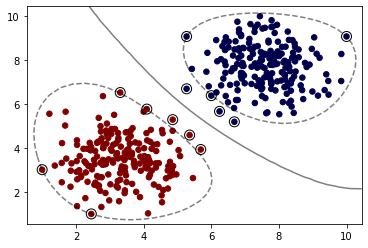

In [ ]:
model = SVC(kernel='rbf', C=1)
model.fit(X, y)
plot_svm_boundary(model, X, y)

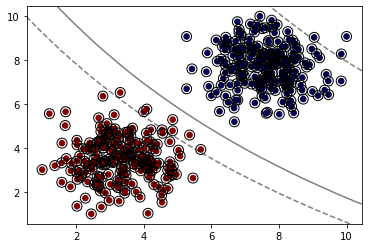

In [ ]:
model = SVC(kernel='sigmoid')
model.fit(X, y)
plot_svm_boundary(model, X, y)

### Polynomial Kernel: Degree Effect

With `kernel='poly'`, the `degree` parameter controls the complexity of the boundary. Degree 1 is equivalent to a linear kernel.

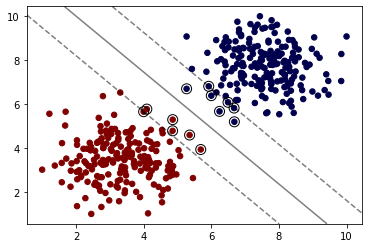

In [ ]:
model = SVC(kernel='poly', C=1, degree=1)
model.fit(X, y)
plot_svm_boundary(model, X, y)

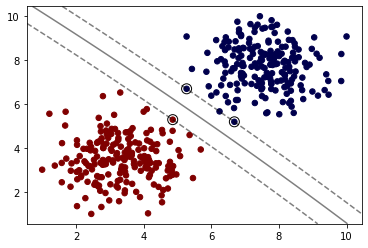

In [ ]:
model = SVC(kernel='poly', C=1, degree=2)
model.fit(X, y)
plot_svm_boundary(model, X, y)

### Gamma: RBF Kernel Sensitivity

Gamma defines how far the influence of a single training point reaches. Low gamma means far-reaching influence (smoother boundary); high gamma means tight local influence (more complex, potentially overfit boundary).

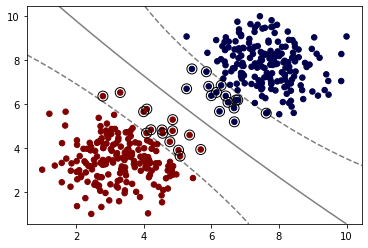

In [ ]:
model = SVC(kernel='rbf', C=1, gamma=0.01)
model.fit(X, y)
plot_svm_boundary(model, X, y)

---
## Part 4: GridSearchCV for Optimal Parameters

A grid search over C and kernel type identifies the combination with the best cross-validated accuracy. Given the clear separation in this dataset, most configurations perform well — the primary value here is demonstrating the search workflow for use in more complex problems.

In [ ]:
svm = SVC()
param_grid = {'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'kernel': ['linear', 'rbf']})

In [ ]:
print('Best score: ', grid.best_score_)
print('Best params:', grid.best_params_)

1.0

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X)
print(classification_report(y, y_pred))

---
*End of project.*